# DK Topic Clusters vs Official Subject Tags

`Embeddings_DK_EP2.ipynb` concluded that DK and EP titles are not close as whole embedding distributions, and that title-embedding similarity is the wrong tool for asking whether two *parliaments'* agendas resemble each other — it can only find individual matched pairs (~17% of DK bills, validated). The better-posed question is agenda-level: does DK legislative attention track EP legislative attention across policy domains over time (the Comparative Agendas Project's actual method), rather than "is title X close to title Y."

That needs a shared topic taxonomy on both sides. Denmark already has one: Folketinget's own open data (oda.ft.dk) tags parliamentary cases with *Sagsområde* (subject-area) labels, human-assigned by parliamentary staff — a real, external, ~250-term controlled vocabulary, already fetched and cached in `Embeddings_DK_EP2.ipynb` as `data/temp_data/parliament/dk_sagsomraade.csv`.

Before spending effort building an EP-side topic classifier to compare against, this notebook checks the prerequisite: **does the DK title-embedding space's unsupervised cluster structure actually recover these real policy-topic categories, or would clustering just be finding phrasing patterns with no topical meaning?** If embeddings can't recover known, human-assigned topics for DK alone, there's no point trusting them to classify EP into the same scheme.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_DIR = Path("..")
DK_PATH = PROJECT_DIR / "data" / "temp_data" / "parliament" / "roll_calls_translated.csv"
SAGSOMRAADE_PATH = PROJECT_DIR / "data" / "temp_data" / "parliament" / "dk_sagsomraade.csv"
EMB_DIR = PROJECT_DIR / "data" / "temp_data" / "embeddings"
RANDOM_STATE = 42

df_dk = pd.read_csv(DK_PATH)
df_dk = df_dk.dropna(subset=["sag_titel_en"]).copy()
df_dk["sag_titel_en"] = df_dk["sag_titel_en"].astype(str).str.strip()
df_dk = df_dk[df_dk["sag_titel_en"].str.len() > 0].reset_index(drop=True)

dk_emb = np.load(EMB_DIR / "dk_title_embeddings_stripped.npy")
assert dk_emb.shape[0] == len(df_dk), "embeddings and titles must be row-aligned"

df_sagsomraade = pd.read_csv(SAGSOMRAADE_PATH)
print(f"DK titles: {len(df_dk):,}")
print(f"Sagsomraade relations: {len(df_sagsomraade):,}  covering {df_sagsomraade['sagid'].nunique():,} cases")

DK titles: 2,128
Sagsomraade relations: 2,261  covering 2,105 cases


In [2]:
tags_per_case = df_sagsomraade.groupby("sagid")["emneord"].apply(lambda s: sorted(set(s)))
df_dk["sagsomraade"] = df_dk["sagid"].map(tags_per_case)
n_tagged = df_dk["sagsomraade"].notna().sum()
n_tags = df_dk["sagsomraade"].dropna().map(len)
print(f"Cases with >=1 Sagsomraade tag: {n_tagged:,} / {len(df_dk):,} ({n_tagged/len(df_dk):.1%})")
print(f"Tags per tagged case: {n_tags.value_counts().sort_index().to_dict()}")

all_tags = df_sagsomraade["emneord"].value_counts()
print(f"\nDistinct Sagsomraade categories in use: {len(all_tags)}")
print(all_tags.head(15))

Cases with >=1 Sagsomraade tag: 2,105 / 2,128 (98.9%)
Tags per tagged case: {1: 1964, 2: 128, 3: 11, 4: 2}

Distinct Sagsomraade categories in use: 253
emneord
strafferet og kriminalitet                62
COVID-19 pandemien                        60
finanspolitik                             42
finansiel virksomhed                      42
folkeskolen                               41
retspleje og domstole                     41
erhvervsdrivende virksomhed               40
EU                                        40
alternative og vedvarende energikilder    36
energiforsyning                           33
indvandrere og integration                32
indfødsrets og naturalisering             31
personskatter                             31
arbejdsløshedsforsikring og dagpenge      30
flygtninge og asylansøgere                28
Name: count, dtype: int64


## Does unsupervised clustering recover these categories?

To test this cleanly, restrict to cases with **exactly one** Sagsomraade tag (93% of tagged cases) so there's an unambiguous "true label," and keep only categories with at least 15 cases so cluster comparison isn't dominated by singleton categories. Run k-means with k = number of surviving categories, and compare against the true labels with Adjusted Rand Index (ARI, 0 = random, 1 = perfect) and Normalized Mutual Information (NMI, same scale) — both computed against a random-label baseline for context, since NMI in particular is inflated by having many small clusters.

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

single = df_dk[df_dk["sagsomraade"].map(lambda t: isinstance(t, list) and len(t) == 1)].copy()
single["category"] = single["sagsomraade"].map(lambda t: t[0])

cat_counts = single["category"].value_counts()
big_cats = cat_counts[cat_counts >= 15].index
eval_df = single[single["category"].isin(big_cats)].copy()
eval_idx = eval_df.index.to_numpy()
X_eval = dk_emb[eval_idx]

print(f"Evaluation set: {len(eval_df):,} cases, {eval_df['category'].nunique()} categories "
      f"(>= 15 cases each, out of {len(all_tags)} total)")

_, y_true = np.unique(eval_df["category"].to_numpy(), return_inverse=True)
k = len(np.unique(y_true))
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_eval)
y_pred = km.labels_

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

rng = np.random.default_rng(RANDOM_STATE)
y_rand = rng.integers(0, k, size=len(y_true))
ari_null = adjusted_rand_score(y_true, y_rand)
nmi_null = normalized_mutual_info_score(y_true, y_rand)

print(f"\nk={k}")
print(f"  ARI: {ari:.3f}  (random-label baseline: {ari_null:.3f})")
print(f"  NMI: {nmi:.3f}  (random-label baseline: {nmi_null:.3f})")

Evaluation set: 1,011 cases, 43 categories (>= 15 cases each, out of 253 total)

k=43
  ARI: 0.335  (random-label baseline: -0.003)
  NMI: 0.655  (random-label baseline: 0.230)


**Reading this:** ARI ≈0.33 (vs ≈0.00 for random labels) and NMI ≈0.65 (vs ≈0.24 for random labels, itself inflated by the many-small-clusters effect) both land well above chance. K-means never sees the Sagsomraade labels — it only has the 768-d title embedding — and it still recovers a substantial share of Folketinget's own subject-area structure. That's the validation this notebook set out to get: **the embedding space encodes real policy-topic content, not just surface phrasing**, which is the prerequisite for trusting it (or a classifier built on it) to assign EP votes into a comparable scheme later.

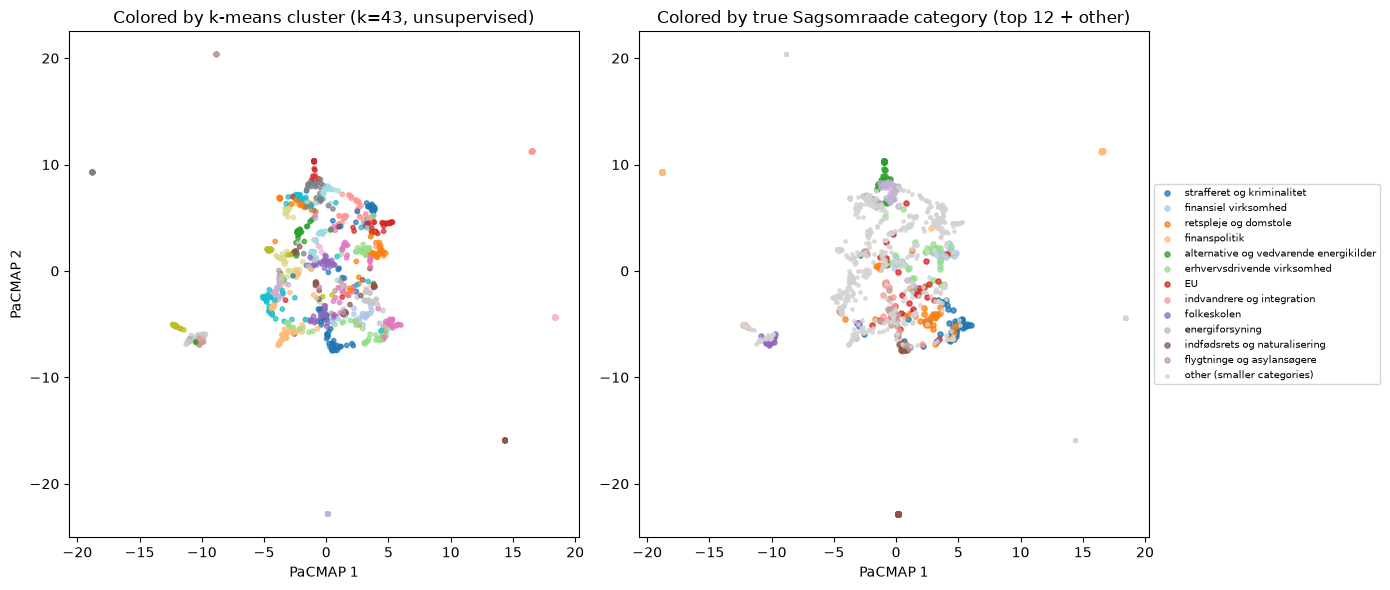

In [4]:
import pacmap
import matplotlib.pyplot as plt

xy = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_eval)

top_cats = cat_counts[cat_counts >= 15].sort_values(ascending=False).index[:12]
cat_arr = eval_df["category"].to_numpy()
color_cat = np.where(np.isin(cat_arr, top_cats), cat_arr, "other (smaller categories)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cmap = plt.get_cmap("tab20")
axes[0].scatter(xy[:, 0], xy[:, 1], c=y_pred, cmap="tab20", s=10, alpha=0.7)
axes[0].set_title(f"Colored by k-means cluster (k={k}, unsupervised)")
axes[0].set_xlabel("PaCMAP 1")
axes[0].set_ylabel("PaCMAP 2")

for i, cat in enumerate(list(top_cats) + ["other (smaller categories)"]):
    mask = color_cat == cat
    color = "lightgray" if cat == "other (smaller categories)" else cmap(i % 20)
    size = 6 if cat == "other (smaller categories)" else 14
    axes[1].scatter(xy[mask, 0], xy[mask, 1], s=size, alpha=0.75, label=cat, color=color)
axes[1].set_title("Colored by true Sagsomraade category (top 12 + other)")
axes[1].set_xlabel("PaCMAP 1")
axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)

plt.tight_layout()
plt.show()

## What do the clusters actually contain?

Print the dominant Sagsomraade categories and a few example titles for a handful of clusters — including some clean ones and some messier ones, for an honest picture rather than cherry-picked wins.

In [5]:
eval_df = eval_df.reset_index(drop=True)
eval_df["cluster"] = y_pred

cluster_sizes = eval_df["cluster"].value_counts()
show_clusters = list(cluster_sizes.index[:4]) + list(cluster_sizes.index[-2:])  # a mix of large and small

for c in show_clusters:
    sub = eval_df[eval_df["cluster"] == c]
    top_cat_counts = sub["category"].value_counts()
    purity = top_cat_counts.iloc[0] / len(sub)
    print(f"\n=== cluster {c}  (n={len(sub)}, purity={purity:.0%}) ===")
    print("category breakdown:", top_cat_counts.head(3).to_dict())
    for t in sub["sag_titel_en"].head(3):
        print("  -", t[:100])


=== cluster 11  (n=49, purity=29%) ===
category breakdown: {'strafferet og kriminalitet': 14, 'retspleje og domstole': 10, 'familieret': 7}
  - Proposal for a law amending the Criminal Code and the Law on the Enforcement of Punishment, etc. (So
  - Proposal for a law amending the adoption law, social services law, parental responsibility law and t
  - Proposal for a law amending the Code of Civil Procedure, the Law on the Court of Justice and the Law

=== cluster 6  (n=46, purity=52%) ===
category breakdown: {'finansiel virksomhed': 24, 'EU': 8, 'skattekontrol': 4}
  - Proposal for a law amending the Law on Financial Activities, the Securities Trading Act, the Payment
  - Proposal for a law amending the Law on Financial Activities (Implementation of the Solvency II and O
  - Proposal for a law amending the Law on Financial Activities, the Law on Financial Stability, the Law

=== cluster 2  (n=43, purity=28%) ===
category breakdown: {'indfødsrets og naturalisering': 12, 'flygtninge og 

## Where this leaves the DK ↔ EP question

The clustering isn't perfect — plenty of cross-cluster leakage, and some clusters mix two or three related-but-distinct Sagsomraade categories (expected: a 43-category taxonomy has real semantic overlap, e.g. "arbejdsmarkedspolitik" and "arbejdsret" aren't cleanly separable from title text alone). But it's not noise either: ARI/NMI are well above the random baseline, and the manual cluster reads above are topically coherent (health/medicines, family law/social services, international taxation, ...). That's enough to trust the embedding space as a foundation for topic work, not enough to skip validation later — any EP-side topic assignment built on the same embeddings should get the same kind of ground-truth check before its numbers are used for anything.

**Open question for the next step, not resolved here:** EP has no equivalent of Sagsomraade. Getting to an actual DK-vs-EP *agenda* comparison (the CAP-style "how much attention does each policy domain get, and does it move together over time" question) needs a way to put EP votes into the same ~40-category scheme. Realistic options, in roughly increasing cost/effort:

1. **`procedure_type` as a coarse proxy** — already available locally, but it's a legislative-procedure axis (binding vs. resolution vs. budget vs. discharge), not a policy-topic axis. Cheap, but answers a different question.
2. **Nearest-Sagsomraade-category by embedding** — encode the ~43 Danish category labels (translate them first, or switch to a multilingual model) and assign each EP title to its nearest category by cosine, the same pattern `topics_ANEY_v1.ipynb` already used for candidate-test questions. Cheap and reuses proven infrastructure, but inherits whatever the DK-side clustering gets wrong, and category labels are short/generic Danish phrases that may not translate to precise EP-matching anchors.
3. **A proper zero-shot or fine-tuned classifier** into the Sagsomraade scheme (or a coarser CAP-style top-level version of it) applied to all 19,634 EP titles — most defensible, most expensive, and needs a decision on granularity (43 categories is probably too fine for EP; CAP's own major-topic scheme is ~20-21 codes, which is closer to what cross-national agenda comparisons actually use).